# Bining / discritization
means conversion of continues to discrite varibales by creaing sets of interval

In [230]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from  sklearn.model_selection import cross_val_score
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer


In [231]:
df= pd.read_csv(r"C:\Users\sus\train.csv", usecols=["Age","Fare","Survived"])

In [232]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [233]:
df.dropna(inplace=True)

In [234]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [235]:
x=df.iloc[:,1:]
y=df.iloc[:,0]

In [236]:
x_train, x_test,y_train,y_test=train_test_split(x,y,test_size=0.2, random_state=42)

In [237]:
x_train.head()

,Age,Fare
328,31.0,20.5250
73,26.0,14.4542
253,30.0,16.1000
719,33.0,7.7750
666,25.0,13.0000


In [238]:
clf=DecisionTreeClassifier()

In [239]:
clf.fit(x_train,y_train)
y_pred=clf.predict(x_test)

In [240]:
accuracy_score(y_test,y_pred)

0.6363636363636364

In [241]:
np.mean(cross_val_score(DecisionTreeClassifier(),x,y,cv=10, scoring="accuracy"))

0.6373239436619718

In [242]:
kbin_age=KBinsDiscretizer(n_bins=15,encode="ordinal",strategy="uniform")
kbin_fare=KBinsDiscretizer(n_bins=15,encode="ordinal",strategy="quantile")

In [243]:
trf=ColumnTransformer([
    ("first",kbin_age,[0]),
    ("second",kbin_fare,[1])
])

In [244]:
x_train_trf=trf.fit_transform(x_train)
x_test_trf=trf.transform(x_test)

In [245]:
trf.named_transformers_

{'first': KBinsDiscretizer(encode='ordinal', n_bins=15, strategy='uniform'),
 'second': KBinsDiscretizer(encode='ordinal', n_bins=15)}

In [246]:
trf.named_transformers_["first"].n_bins_

array([15])

In [247]:
trf.named_transformers_["first"].bin_edges_

array([array([ 0.42      ,  5.72533333, 11.03066667, 16.336     , 21.64133333,
              26.94666667, 32.252     , 37.55733333, 42.86266667, 48.168     ,
              53.47333333, 58.77866667, 64.084     , 69.38933333, 74.69466667,
              80.        ])                                                   ],
      dtype=object)

In [248]:
trf.named_transformers_["second"].bin_edges_

array([array([  0.    ,   7.25  ,   7.775 ,   7.8958,   8.1583,  10.5   ,
               13.    ,  14.4542,  18.75  ,  26.    ,  26.55  ,  31.275 ,
               51.4792,  76.2917, 108.9   , 512.3292])                   ],
      dtype=object)

In [249]:

output = pd.DataFrame({
    'age':x_train['Age'],
    'age_trf':x_train_trf[:,0],
    'fare':x_train['Fare'],
    'fare_trf':x_train_trf[:,1]
})

In [250]:

output['age_labels'] = pd.cut(x=x_train['Age'],
                                    bins=trf.named_transformers_['first'].bin_edges_[0].tolist())
output['fare_labels'] = pd.cut(x=x_train['Fare'],
                                    bins=trf.named_transformers_['second'].bin_edges_[0].tolist())

In [251]:
output.sample(5)


,age,age_trf,fare,fare_trf,age_labels,fare_labels
96,71.0,13.0,34.6542,11.0,"(69.389, 74.695]","(31.275, 51.479]"
445,4.0,0.0,81.8583,13.0,"(0.42, 5.725]","(76.292, 108.9]"
748,19.0,3.0,53.1000,12.0,"(16.336, 21.641]","(51.479, 76.292]"
722,34.0,6.0,13.0000,6.0,"(32.252, 37.557]","(10.5, 13.0]"
10,4.0,0.0,16.7000,7.0,"(0.42, 5.725]","(14.454, 18.75]"


In [252]:

clf = DecisionTreeClassifier()
clf.fit(x_train_trf,y_train)
y_pred2 = clf.predict(x_test_trf)

In [253]:
accuracy_score(y_test,y_pred2)


0.6363636363636364

In [254]:
X_trf = trf.fit_transform(x)
np.mean(cross_val_score(DecisionTreeClassifier(),x,y,cv=10,scoring='accuracy'))

0.630281690140845

In [255]:
def discretize(bins,strategy):
    kbin_age = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    kbin_fare = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    
    trf = ColumnTransformer([
        ('first',kbin_age,[0]),
        ('second',kbin_fare,[1])
    ])
    
    X_trf = trf.fit_transform(x)
    print(np.mean(cross_val_score(DecisionTreeClassifier(),x,y,cv=10,scoring='accuracy')))
    
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(x['Age'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,0],color='red')
    plt.title("After")

    plt.show()
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(x['Fare'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,1],color='red')
    plt.title("Fare")

    plt.show()
    
    

C:\Users\sus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\Users\sus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


0.6274647887323944


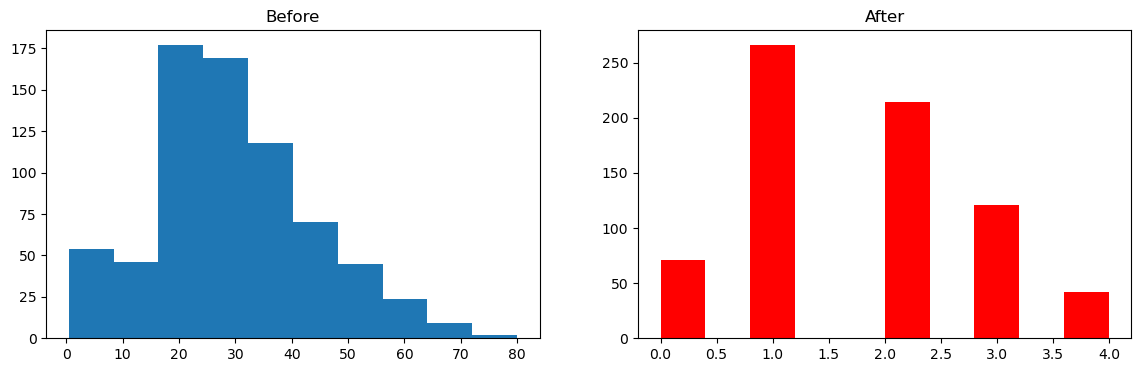

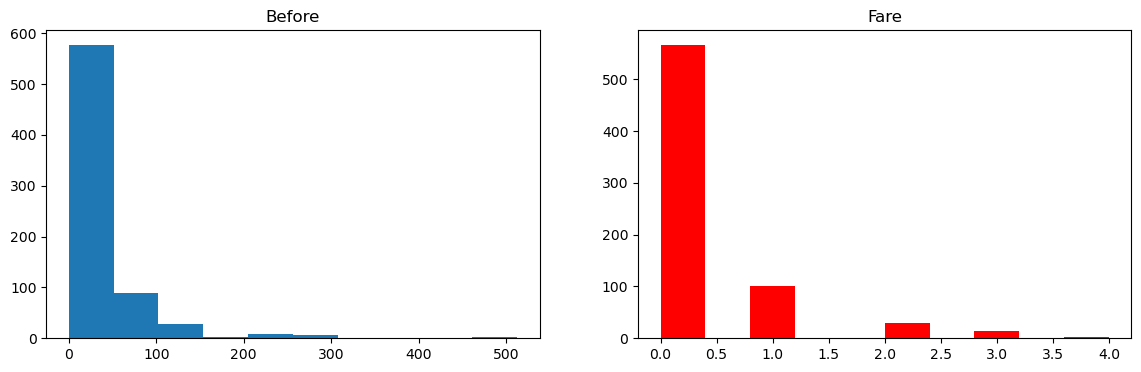

In [256]:
discretize(5,'kmeans')


0.6344874804381846


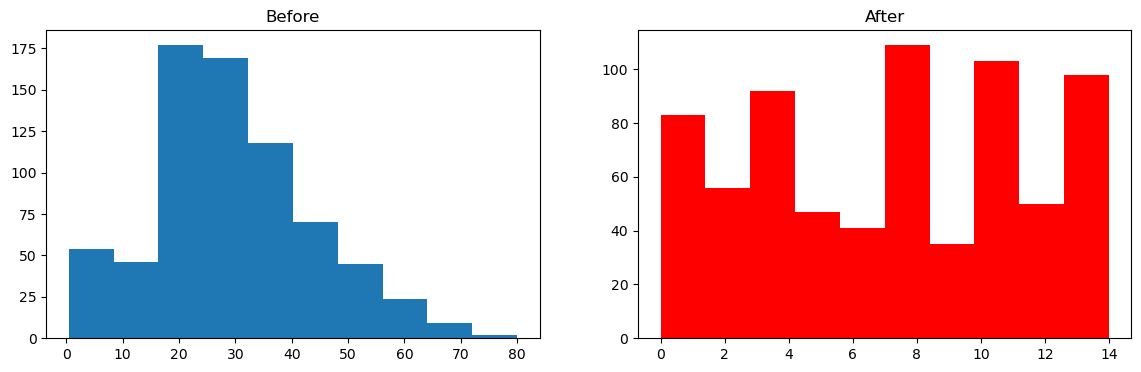

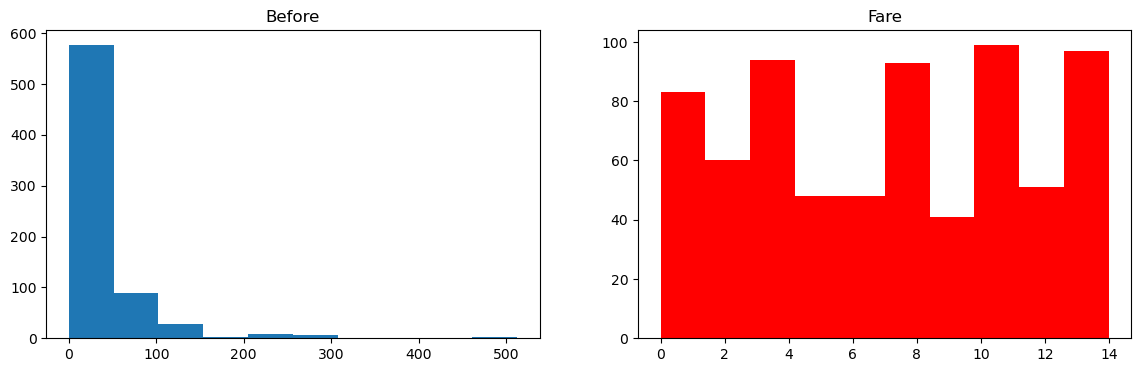

In [257]:
discretize(15,"quantile")

0.630281690140845


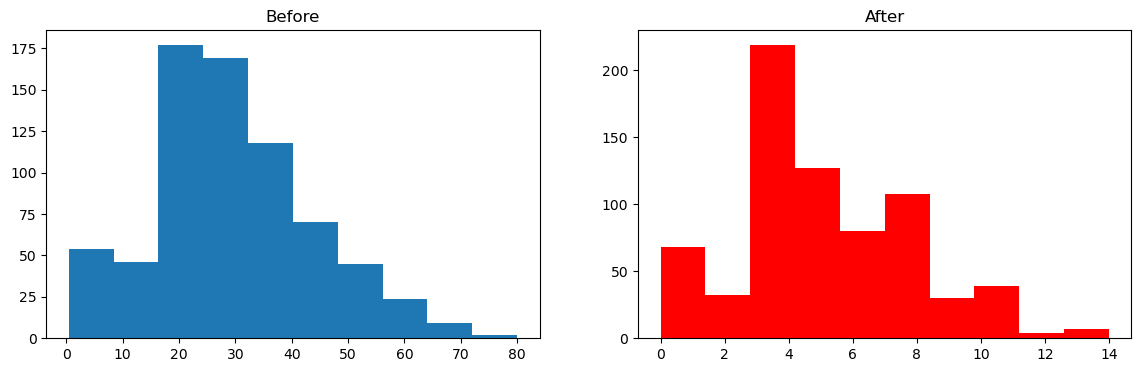

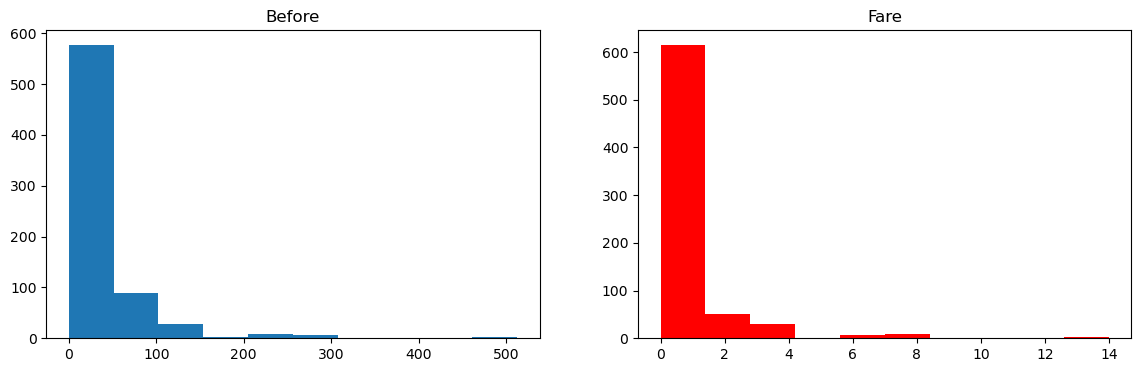

In [259]:
discretize(15,"uniform")

###  custom or doamin based binning can be done using pandas , we need to write a custom code , no class for it in sklearn
